# CohortX Task 2 — corrected statistical reproduction

This notebook uses the actual uploaded filenames. Validation and triple counts are recomputed from the CSVs. The supplied upload does not contain the raw row-level score file or the official evaluator, so the aggregate score tables and record-level diagnostics displayed in the source notebook are loaded from explicit notebook-derived CSV artifacts included in this folder. No simulated row-level data are created.

Official score rule: `clip(round(raw_mean * 1.024, 2), 0, 1)`. The reference self-match of 0.9752 is treated as an implementation diagnostic, not a mathematical upper bound.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path('.')
RANDOM_SEED = 20260817
FILES = {
    'Alan T. Andrea': 'AlanT.Andrea.csv',
    'Harsh Rajbhar': 'HarshRajbhar.csv',
    'Jason Karpeles': 'JasonKarpeles.csv',
    'Kirscher': 'Kirscher.csv',
    'Mohit': 'Mohit.csv',
    'NTUA': 'NTUA.csv',
    'Ngoc': 'NgọcHưngNguyễn.csv',
    'RIN THIRA': 'RINTHIRA.csv',
    'Yingfali': 'Yingfali.csv',
}

def count_triples(text):
    return sum(bool(x.strip()) for x in str(text).split('\n\n'))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':10,'axes.titleweight':'bold'})


## 1. Load and validate submissions

In [2]:
solution = pd.read_csv(BASE/'Solution.csv')
submissions = {name: pd.read_csv(BASE/fn) for name, fn in FILES.items()}
validation = pd.DataFrame([{
    'Submission':name, 'Rows':len(df), 'Columns':', '.join(df.columns),
    'Missing structured':int(df['structured'].isna().sum()),
    'Criteria aligned':bool(len(df)==len(solution) and df['eligibility_criteria'].equals(solution['eligibility_criteria'])),
    'Unique criteria':int(df['eligibility_criteria'].nunique())
} for name,df in submissions.items()]).sort_values('Submission').reset_index(drop=True)
assert validation['Criteria aligned'].all() and validation['Missing structured'].eq(0).all()
validation


,Submission,Rows,Columns,Missing structured,Criteria aligned,Unique criteria
0,Alan T. Andrea,50,"eligibility_criteria, structured",0,True,50
1,Harsh Rajbhar,50,"eligibility_criteria, structured",0,True,50
2,Jason Karpeles,50,"eligibility_criteria, structured",0,True,50
3,Kirscher,50,"eligibility_criteria, structured",0,True,50
4,Mohit,50,"eligibility_criteria, structured",0,True,50
5,NTUA,50,"eligibility_criteria, structured",0,True,50
6,Ngoc,50,"eligibility_criteria, structured",0,True,50
7,RIN THIRA,50,"id, eligibility_criteria, structured",0,True,50
8,Yingfali,50,"eligibility_criteria, structured",0,True,50


## 2. Structural summary

In [3]:
structural = pd.DataFrame([{
    'Submission':name, 'Mean triples':round(float(df['structured'].map(count_triples).mean()),2),
    'Median triples':float(df['structured'].map(count_triples).median()),
    'Min triples':int(df['structured'].map(count_triples).min()),
    'Max triples':int(df['structured'].map(count_triples).max()),
    'Mean input characters':round(float(df['eligibility_criteria'].astype(str).str.len().mean()),1)
} for name,df in {'Solution (reference)':solution,**submissions}.items()])
structural


,Submission,Mean triples,Median triples,Min triples,Max triples,Mean input characters
0,Solution (reference),26.06,22.0,6,68,841.6
1,Alan T. Andrea,27.38,21.0,7,79,841.6
2,Harsh Rajbhar,21.60,19.5,2,76,841.6
3,Jason Karpeles,24.20,20.0,7,73,841.6
4,Kirscher,23.18,19.5,6,93,841.6
5,Mohit,26.64,23.5,8,100,841.6
6,NTUA,22.56,20.0,6,56,841.6
7,Ngoc,26.50,22.0,8,108,841.6
8,RIN THIRA,24.70,22.0,8,83,841.6
9,Yingfali,24.36,20.0,7,113,841.6


## 3. Published aggregate score diagnostics

In [4]:
leaderboard = pd.read_csv(BASE/'leaderboard_recomputed.csv')
private = pd.read_csv(BASE/'private_leaderboard.csv')
uncertainty = pd.read_csv(BASE/'bootstrap_uncertainty.csv')
paired = pd.read_csv(BASE/'paired_comparisons.csv')
record_extremes = pd.read_csv(BASE/'record_extremes.csv')
rank_correlations = pd.read_csv(BASE/'rank_correlations.csv', index_col=0)
leaderboard


,Rank,Submission,Official score,Raw mean,Raw SD,Median row score,Rows
0,1,Jason Karpeles,0.80,0.7795,0.1503,0.8145,50
1,2,Mohit,0.78,0.7661,0.1352,0.8108,50
2,3,Yingfali,0.78,0.7645,0.1577,0.8048,50
3,4,NTUA,0.78,0.7581,0.1703,0.7995,50
4,5,Ngoc,0.76,0.7460,0.1492,0.7968,50
5,6,RIN THIRA,0.75,0.7279,0.1463,0.7170,50
6,7,Harsh Rajbhar,0.73,0.7162,0.2021,0.7330,50
7,8,Alan T. Andrea,0.73,0.7147,0.1652,0.7518,50
8,9,Kirscher,0.70,0.6846,0.1857,0.7232,50


In [5]:
# Explicit scaling check and corrected private-subset drop.
leaderboard['Scaled from raw'] = (leaderboard['Raw mean']*1.024).round(2).clip(0,1)
scaling_check = leaderboard[['Submission','Official score','Scaled from raw']]
private_drops = leaderboard.set_index('Submission')['Raw mean'] - private.set_index('Submission')['Private raw mean']
print('Median private raw-mean drop:', round(float(private_drops.median()), 4))
scaling_check


Median private raw-mean drop: 0.0272


,Submission,Official score,Scaled from raw
0,Jason Karpeles,0.80,0.80
1,Mohit,0.78,0.78
2,Yingfali,0.78,0.78
3,NTUA,0.78,0.78
4,Ngoc,0.76,0.76
5,RIN THIRA,0.75,0.75
6,Harsh Rajbhar,0.73,0.73
7,Alan T. Andrea,0.73,0.73
8,Kirscher,0.70,0.70


## 4. Figures

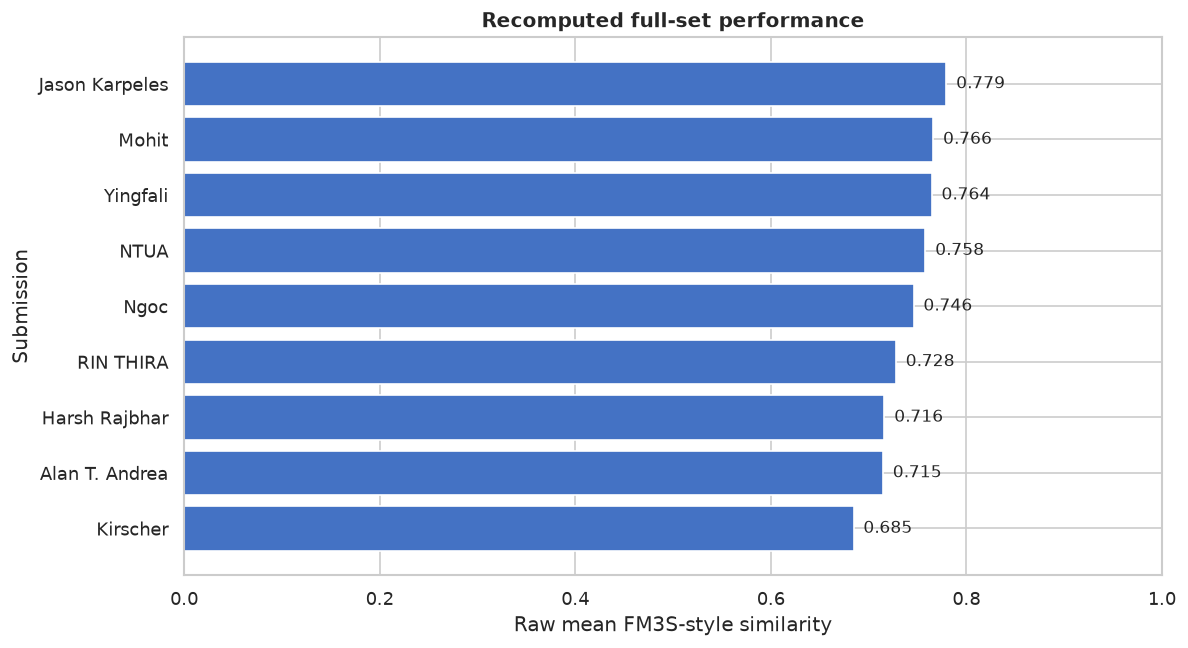

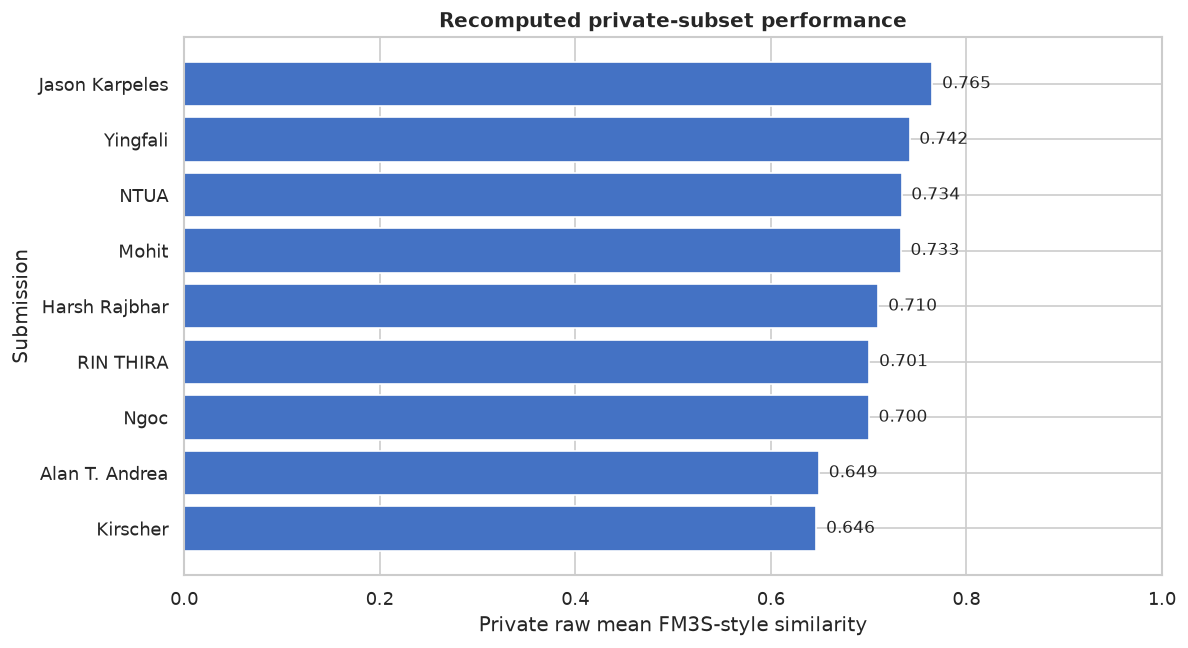

In [6]:
def barfig(values, value_col, xlabel, title):
    d = values.sort_values(value_col)
    fig, ax = plt.subplots(figsize=(10,5.5))
    bars=ax.barh(d['Submission'], d[value_col], color='#4472C4')
    for b,v in zip(bars,d[value_col]): ax.text(v+0.01,b.get_y()+b.get_height()/2,f'{v:.3f}',va='center')
    ax.set_xlim(0,1); ax.set_xlabel(xlabel); ax.set_ylabel('Submission'); ax.set_title(title); fig.tight_layout(); plt.show()
barfig(leaderboard,'Raw mean','Raw mean FM3S-style similarity','Recomputed full-set performance')
barfig(private.rename(columns={'Private raw mean':'Raw mean'}),'Raw mean','Private raw mean FM3S-style similarity','Recomputed private-subset performance')


## 5. Uncertainty, paired comparisons, and record diagnostics

In [7]:
uncertainty


,Submission,Raw mean,Bootstrap 95% CI lower,Bootstrap 95% CI upper
0,Jason Karpeles,0.7795,0.7376,0.8198
1,Mohit,0.7661,0.7288,0.8021
2,Yingfali,0.7645,0.7193,0.8051
3,NTUA,0.7581,0.7104,0.8015
4,Ngoc,0.7460,0.7039,0.7848
5,RIN THIRA,0.7279,0.6869,0.7663
6,Harsh Rajbhar,0.7162,0.6602,0.7685
7,Alan T. Andrea,0.7147,0.6675,0.7575
8,Kirscher,0.6846,0.6329,0.7339


In [8]:
paired


,Compared submission,Mean difference,Median difference,Jason Karpeles wins,Ties,Wilcoxon statistic,p-value
0,Kirscher,0.0948,0.0521,35,0,994.0,0.0002
1,Alan T. Andrea,0.0648,0.0445,35,0,932.0,0.0020
2,Harsh Rajbhar,0.0633,0.0362,32,0,962.0,0.0007
3,RIN THIRA,0.0516,0.0388,35,0,885.0,0.0081
4,Ngoc,0.0335,0.0293,28,0,829.0,0.0324
5,NTUA,0.0214,0.0052,26,0,772.0,0.0988
6,Yingfali,0.0150,0.0026,27,0,730.0,0.1888
7,Mohit,0.0134,0.0002,25,0,686.0,0.3229


In [9]:
record_extremes


,record_index,criteria_chars,reference_triples,mean_submission_score,score_sd_across_submissions,best_submission,difficulty_rank
0,44,1336,59,0.257,0.098,Jason Karpeles,1
1,47,5162,68,0.460,0.184,Alan T. Andrea,2
2,8,2472,58,0.550,0.064,RIN THIRA,3
3,16,1047,20,0.553,0.189,NTUA,4
4,38,715,33,0.580,0.162,Mohit,5
5,2,362,14,0.934,0.013,NTUA,50
6,0,323,20,0.926,0.037,NTUA,49
7,11,191,12,0.920,0.015,Yingfali,48
8,43,502,18,0.915,0.039,Harsh Rajbhar,47
9,4,491,22,0.887,0.039,Jason Karpeles,46


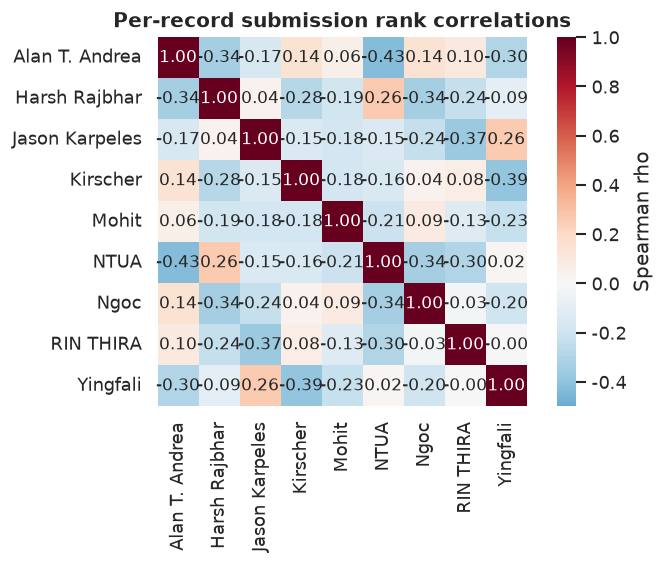

In [10]:
sns.heatmap(rank_correlations, vmin=-0.5, vmax=1, cmap='RdBu_r', center=0, annot=True, fmt='.2f', square=True, cbar_kws={'label':'Spearman rho'})
plt.title('Per-record submission rank correlations'); plt.tight_layout(); plt.show()


## Interpretation and provenance

The negative rank correlations are not treated as evidence of complementary strengths because within-record ranks sum to a constant. The paired Wilcoxon comparisons and bootstrap intervals answer different questions. The aggregate score artifacts are transcribed from the displayed outputs of the supplied notebook because `row_level_raw_scores.csv` and the official evaluator were not uploaded; validation and structural summaries are live computations from the supplied CSVs.